# 04a — Distance to Nearest MRT Station

**Objective**: Compute the straight-line distance (metres) from each factory to its nearest MRT/LRT station.

**Approach**:
1. Geocode unique `Project Name` / `Street Name` via OneMap API → get lat/long per building
2. Compute Haversine distance from each building to all 193 MRT/LRT stations
3. Keep minimum distance per building
4. Merge back to `factory_engineered.csv` on `Project Name`
5. Save updated `factory_engineered.csv` with `dist_to_mrt_m` column

**Input**: `data/processed/factory_engineered.csv`, `data/raw/external/mrt_lrt.csv`  
**Output**: `data/processed/factory_engineered.csv` (updated with `dist_to_mrt_m`)

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time
from math import radians
from sklearn.metrics.pairwise import haversine_distances

df = pd.read_csv("../data/processed/factory_engineered.csv")
mrt_df = pd.read_csv("../data/raw/external/mrt_lrt.csv")

# Standardise MRT column names
mrt_df = mrt_df[["Name", "Latitude", "Longitude"]].rename(columns={
    "Name": "mrt_station",
    "Latitude": "latitude",
    "Longitude": "longitude"
})

print(f"Factory dataset:  {df.shape[0]} rows, {df['Project Name'].nunique()} unique buildings")
print(f"Missing Project Name: {df['Project Name'].isna().sum()} rows (will fallback to Street Name)")
print(f"MRT/LRT stations: {len(mrt_df)}")

Factory dataset:  3789 rows, 147 unique buildings
Missing Project Name: 26 rows (will fallback to Street Name)
MRT/LRT stations: 193


## 2. Geocode Unique Buildings via OneMap API

OneMap API geocodes a search term (building name or street name) and returns lat/long.

**Strategy**:
- Try `Project Name` first
- Fall back to `Street Name` if Project Name returns no results
- Only call API once per unique building — 148 API calls total
- Add 0.2s delay between calls to avoid rate limiting

In [2]:
def geocode_onemap(search_term):
    """Query OneMap API and return (latitude, longitude) or (None, None) if not found."""
    url = "https://www.onemap.gov.sg/api/common/elastic/search"
    params = {"searchVal": search_term, "returnGeom": "Y", "getAddrDetails": "Y"}
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        if data["found"] > 0:
            result = data["results"][0]
            return float(result["LATITUDE"]), float(result["LONGITUDE"])
    except Exception:
        pass
    return None, None


def geocode_buildings(df):
    """
    Geocode all unique buildings via OneMap API.
    search_key = Project Name if available, else Street Name.
    Deduplicates by search_key to avoid redundant API calls.
    """
    temp = df[["Project Name", "Street Name"]].copy()
    temp["search_key"] = temp["Project Name"].fillna(temp["Street Name"])
    unique_buildings = temp.drop_duplicates("search_key").reset_index(drop=True)

    results = []
    total = len(unique_buildings)

    for i, row in unique_buildings.iterrows():
        search_key = row["search_key"]
        lat, lon = geocode_onemap(search_key)
        results.append({
            "search_key": search_key,
            "Project Name": row["Project Name"],
            "Street Name": row["Street Name"],
            "latitude": lat,
            "longitude": lon,
        })
        if (i + 1) % 10 == 0:
            print(f"  Geocoded {i + 1}/{total}...")
        time.sleep(0.2)

    geo_df = pd.DataFrame(results)
    failed = geo_df[geo_df["latitude"].isna()]
    if not failed.empty:
        failed_list = failed[["search_key", "Project Name", "Street Name"]].to_string()
        raise ValueError(f"Geocoding failed for {len(failed)} building(s):\n{failed_list}\nFix and re-run.")
    print(f"\nGeocoding complete: {len(geo_df)}/{total} successful")
    return geo_df


In [3]:
print("Starting geocoding...")
geo_df = geocode_buildings(df)
display(geo_df.head(10))

Starting geocoding...


  Geocoded 10/150...


  Geocoded 20/150...


  Geocoded 30/150...


  Geocoded 40/150...


...

  Geocoded 120/150...


  Geocoded 130/150...


  Geocoded 140/150...


  Geocoded 150/150...

Geocoding complete: 150/150 successful


,search_key,Project Name,Street Name,latitude,longitude
0,PREMIER @ KAKI BUKIT,PREMIER @ KAKI BUKIT,KAKI BUKIT AVENUE 4,1.338567,103.905877
1,FOCUS ONE,FOCUS ONE,UBI VIEW,1.331652,103.897019
2,GOURMET EAST KITCHEN,GOURMET EAST KITCHEN,BEDOK NORTH STREET 5,1.337027,103.946046
3,T-SPACE,T-SPACE,TAMPINES NORTH DRIVE 1,1.371532,103.934204
4,FRONTIER,FRONTIER,UBI AVENUE 3,1.330975,103.895778
5,ENTERPRISE ONE,ENTERPRISE ONE,KAKI BUKIT ROAD 1,1.332765,103.902676
6,PRIMZ BIZHUB,PRIMZ BIZHUB,WOODLANDS CLOSE,1.435024,103.804761
7,WCEGA TOWER,WCEGA TOWER,BUKIT BATOK CRESCENT,1.336966,103.759665
8,ONE@REDHILL CENTRE,ONE@REDHILL CENTRE,JALAN KILANG BARAT,1.284965,103.808546
9,WOODLANDS CONNECTION,WOODLANDS CONNECTION,WOODLANDS SECTOR 2,1.461249,103.808667


## 3. Compute Distance to Nearest MRT Station

Uses **Haversine distance** — straight-line distance on the surface of a sphere.

For each building, compute distance to all 193 MRT/LRT stations and keep the minimum.

Distance is converted from km to **metres**.

In [4]:
def compute_nearest_mrt(geo_df, mrt_df):
    """Compute distance to nearest MRT station for each building in metres."""
    valid = geo_df.copy()

    min_distances = []
    nearest_stations = []

    for _, row in valid.iterrows():
        prop_coords_rad = [radians(row["latitude"]), radians(row["longitude"])]

        distances = []
        for _, mrt_row in mrt_df.iterrows():
            mrt_coords_rad = [radians(mrt_row["latitude"]), radians(mrt_row["longitude"])]
            dist_km = haversine_distances([prop_coords_rad, mrt_coords_rad])[0][1] * 6371
            distances.append((dist_km * 1000, mrt_row["mrt_station"]))

        min_dist, nearest = min(distances, key=lambda x: x[0])
        min_distances.append(round(min_dist, 1))
        nearest_stations.append(nearest)

    valid["dist_to_mrt_m"] = min_distances
    valid["nearest_mrt"] = nearest_stations

    return valid[["search_key", "Project Name", "Street Name", "dist_to_mrt_m", "nearest_mrt"]]


In [5]:
mrt_dist_df = compute_nearest_mrt(geo_df, mrt_df)

print(f"Distance computed for {len(mrt_dist_df)} buildings")
print(f"\nDistance statistics (metres):")
print(mrt_dist_df["dist_to_mrt_m"].describe().round(1).to_string())

print(f"\nClosest to MRT:")
display(mrt_dist_df.nsmallest(5, "dist_to_mrt_m")[["Project Name", "nearest_mrt", "dist_to_mrt_m"]])

print(f"\nFarthest from MRT:")
display(mrt_dist_df.nlargest(5, "dist_to_mrt_m")[["Project Name", "nearest_mrt", "dist_to_mrt_m"]])

Distance computed for 150 buildings

Distance statistics (metres):
count     150.0
mean     1223.0
std       920.8
min       162.7
25%       598.2
50%       977.9
75%      1601.2
max      6113.1

Closest to MRT:


,Project Name,nearest_mrt,dist_to_mrt_m
84,CT HUB,BENDEMEER MRT STATION,162.7
96,HOLA CENTRE,UBI MRT STATION,228.2
50,CT HUB 2,BENDEMEER MRT STATION,235.9
118,THE COMMERZE@IRVING,TAI SENG MRT STATION,255.6
124,TECHNIQUES CENTRE,UBI MRT STATION,258.9



Farthest from MRT:


,Project Name,nearest_mrt,dist_to_mrt_m
127,TUAS SOUTH CONNECTION,TUAS CRESCENT MRT STATION,6113.1
74,SHINE@TUAS SOUTH,TUAS CRESCENT MRT STATION,5984.1
119,T99,TUAS CRESCENT MRT STATION,4687.5
115,NaN,TUAS CRESCENT MRT STATION,3300.2
94,WESTLINK TWO,TUAS CRESCENT MRT STATION,3222.4


## 4. Validate — Correlation with Target

Rows matched:  3789 / 3789
Rows missing:  0 (failed geocoding)
Correlation with Unit Price ($ psf): r = -0.316


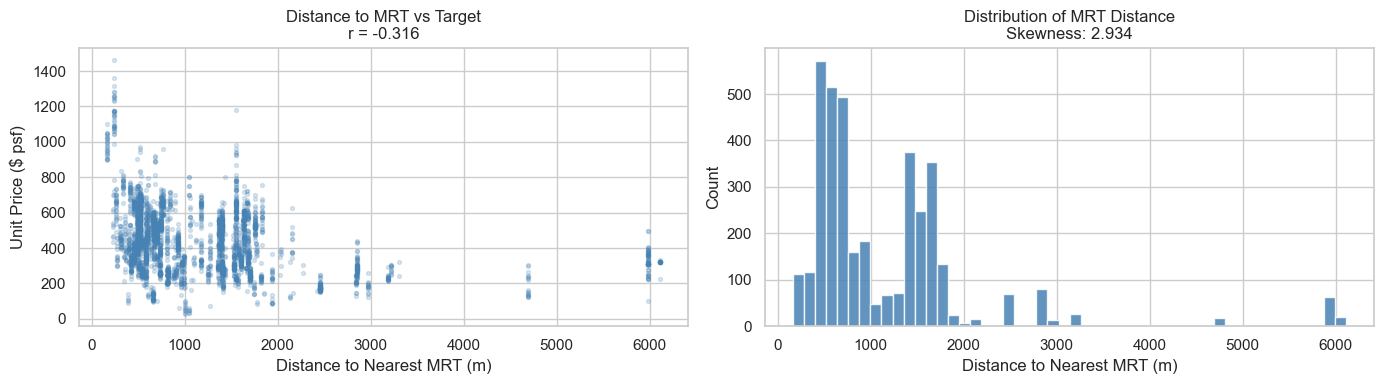

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# Build search_key on transactions: Project Name if available, else Street Name
df["search_key"] = df["Project Name"].fillna(df["Street Name"])

df_check = df.merge(mrt_dist_df[["search_key", "dist_to_mrt_m"]], on="search_key", how="left")

print(f"Rows matched:  {df_check['dist_to_mrt_m'].notna().sum()} / {len(df_check)}")
print(f"Rows missing:  {df_check['dist_to_mrt_m'].isna().sum()} (failed geocoding)")

r = df_check["dist_to_mrt_m"].corr(df_check["Unit Price ($ psf)"])
print(f"Correlation with Unit Price ($ psf): r = {r:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(df_check["dist_to_mrt_m"], df_check["Unit Price ($ psf)"],
                alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("Distance to Nearest MRT (m)")
axes[0].set_ylabel("Unit Price ($ psf)")
axes[0].set_title(f"Distance to MRT vs Target\nr = {r:.3f}")
axes[1].hist(df_check["dist_to_mrt_m"].dropna(), bins=50,
             color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Distance to Nearest MRT (m)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Distribution of MRT Distance\nSkewness: {df_check['dist_to_mrt_m'].skew():.3f}")
plt.tight_layout()
plt.show()


## 5. Merge & Save Updated Dataset

In [7]:
# Build search_key on transactions: Project Name if available, else Street Name
df["search_key"] = df["Project Name"].fillna(df["Street Name"])

df_updated = df.merge(
    mrt_dist_df[["search_key", "dist_to_mrt_m", "nearest_mrt"]],
    on="search_key",
    how="left"
)

# Drop helper column — not a feature
df_updated = df_updated.drop(columns=["search_key"])

missing = df_updated["dist_to_mrt_m"].isna().sum()
print(f"Rows with dist_to_mrt_m:    {df_updated['dist_to_mrt_m'].notna().sum()} / {len(df_updated)}")
print(f"Rows missing dist_to_mrt_m: {missing} (failed geocoding)")

df_updated.to_csv("../data/processed/factory_engineered.csv", index=False)
mrt_dist_df.to_csv("../data/processed/property_geocoded.csv", index=False)

print(f"\nSaved:")
print(f"  data/processed/factory_engineered.csv  (shape: {df_updated.shape})")
print(f"  data/processed/property_geocoded.csv")
print(f"\nCorrelation with target: r = {df_updated['dist_to_mrt_m'].corr(df_updated['Unit Price ($ psf)']):.3f}")


Rows with dist_to_mrt_m:    3789 / 3789
Rows missing dist_to_mrt_m: 0 (failed geocoding)

Saved:
  data/processed/factory_engineered.csv  (shape: (3789, 30))
  data/processed/property_geocoded.csv

Correlation with target: r = -0.316
